In [23]:
pip install mlflow scikit-learn pandas numpy matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic equipment data
n_samples = 10000

# Features
temperature = np.random.normal(75, 15, n_samples)   # °C
vibration = np.random.normal(0.5, 0.2, n_samples)   # mm/s
pressure = np.random.normal(100, 20, n_samples)     # PSI
rpm = np.random.normal(1500, 200, n_samples)        # RPM
age_days = np.random.randint(0, 365, n_samples)     # Days since last maintenance

# Create failure condition (combination of factors)
failure_score = (
    (temperature > 90) * 0.3 +
    (vibration > 0.8) * 0.3 +
    (pressure > 130) * 0.2 +
    (age_days > 300) * 0.2
)

# Add some randomness
failure_prob = failure_score + np.random.normal(0, 0.1, n_samples)
failure = (failure_prob > 0.5).astype(int)

# Create DataFrame
data = pd.DataFrame({
    'temperature': temperature,
    'vibration': vibration,
    'pressure': pressure,
    'rpm': rpm,
    'age_days': age_days,
    'failure': failure
})

print(f"Dataset shape: {data.shape}")
print(f"Failure rate: {data.failure.mean():.2%}")

data.head()

Dataset shape: (10000, 6)
Failure rate: 4.15%


,temperature,vibration,pressure,rpm,age_days,failure
0,82.450712,0.364301,106.965725,1103.885606,187,0
1,72.926035,0.438900,105.666472,1289.002871,239,0
2,84.715328,0.380524,81.269603,1382.594319,2,0
3,97.845448,0.522084,111.591684,1529.933782,5,0
4,71.487699,0.739436,70.198346,1704.832465,259,0



Summary Statistics:
        temperature     vibration      pressure           rpm      age_days  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      74.967960      0.502707     99.750745   1498.485705    181.908000   
std       15.051936      0.200202     19.828363    200.897414    105.568632   
min       16.163996     -0.271275     26.898270    606.879227      0.000000   
25%       64.911142      0.367598     85.996962   1361.077430     90.000000   
50%       74.961075      0.503169     99.884635   1497.923551    182.000000   
75%       85.066213      0.638773    113.277949   1635.806091    272.000000   
max      133.893566      1.395817    173.832490   2245.566669    364.000000   

            failure  
count  10000.000000  
mean       0.041500  
std        0.199454  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max        1.000000  

Missing values:
temperature    0
vibration      0
pressure       0
r

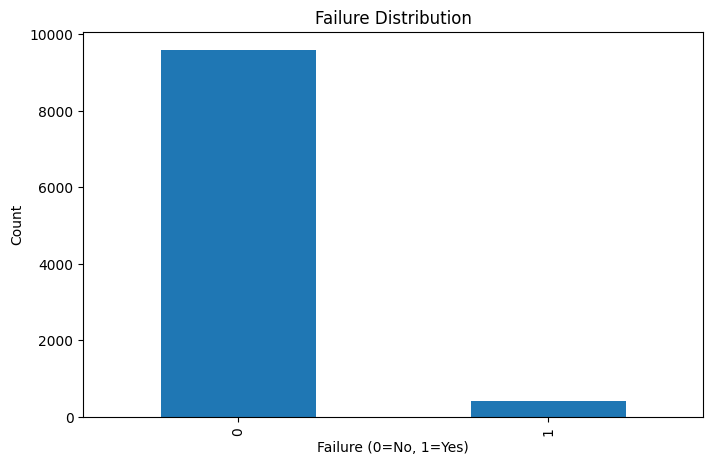

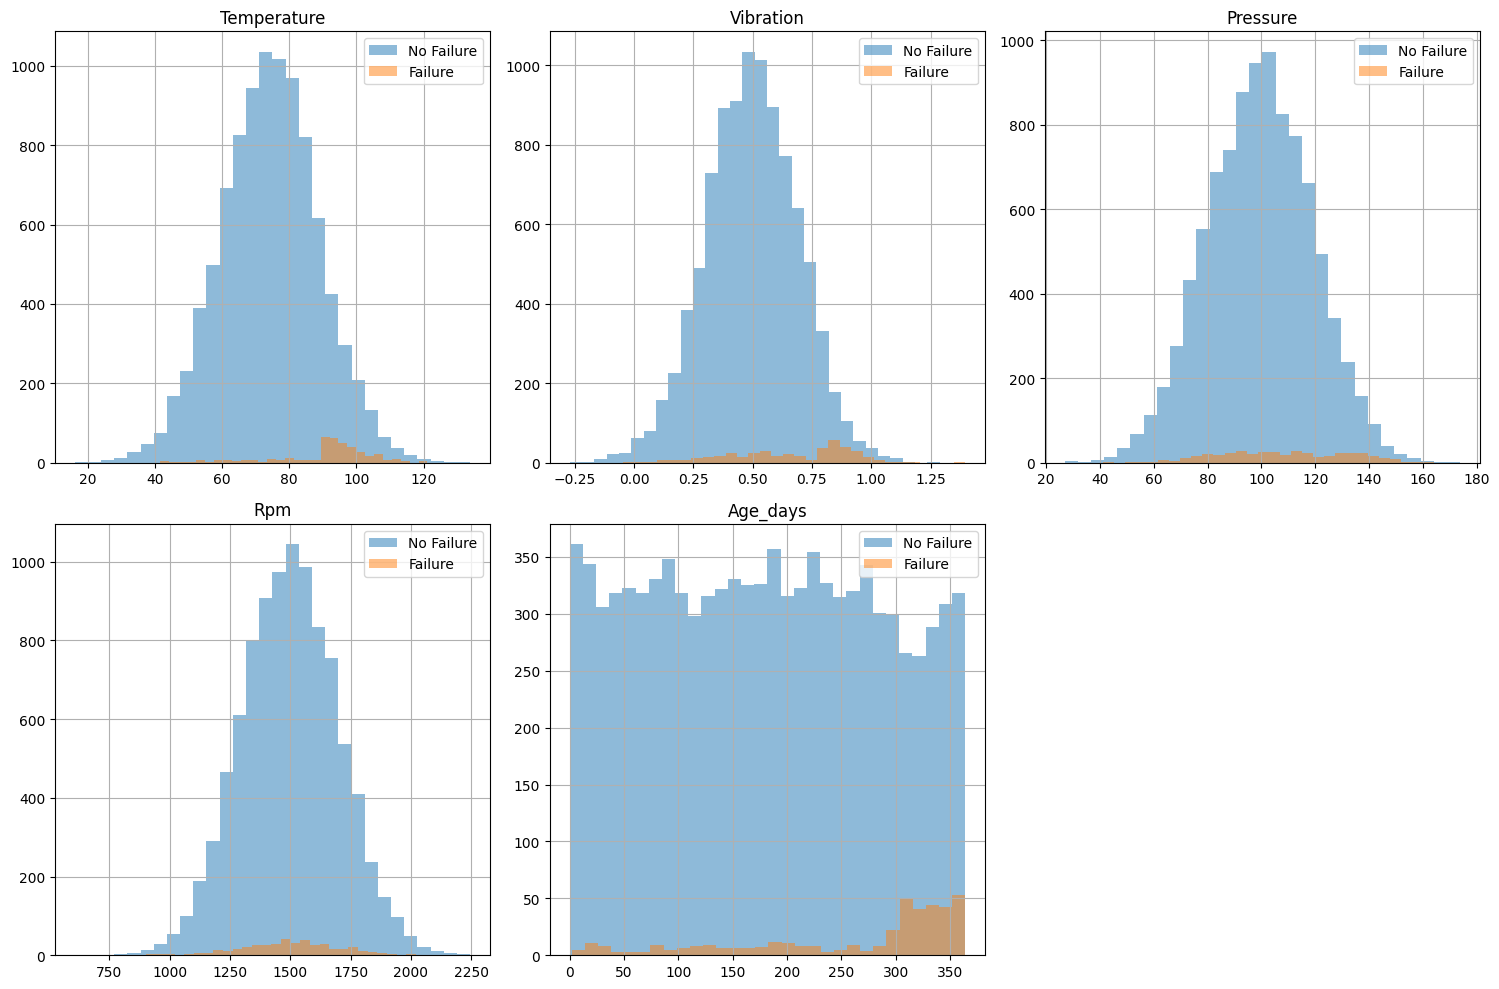

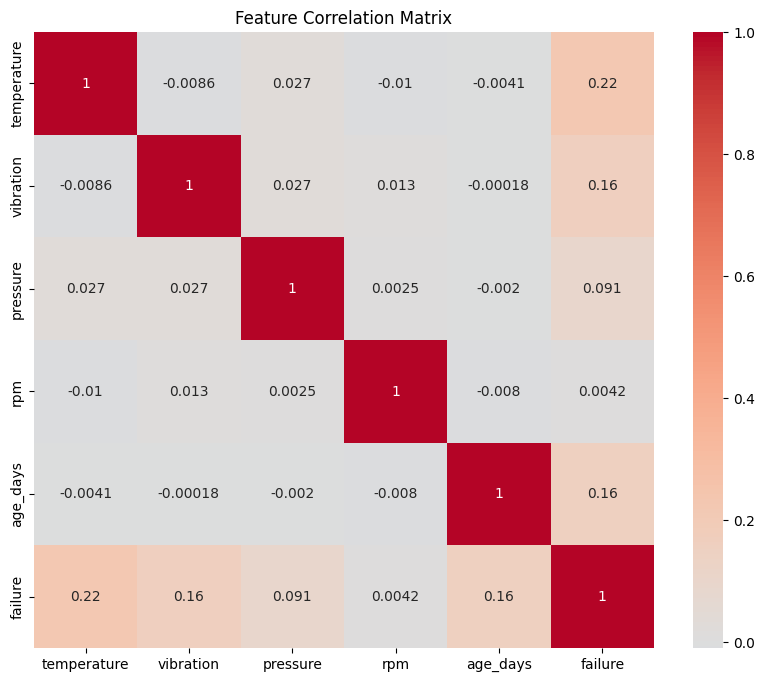

In [25]:
# Summary statistics
print("\nSummary Statistics:")
print(data.describe())

# Check for missing values
print("\nMissing values:")
print(data.isnull().sum())

# Class distribution
plt.figure(figsize=(8, 5))
data.failure.value_counts().plot(kind="bar")
plt.title("Failure Distribution")
plt.xlabel("Failure (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

# Feature distributions by class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ["temperature", "vibration", "pressure", "rpm", "age_days"]

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]

    data[data.failure == 0][feature].hist(
        ax=ax,
        alpha=0.5,
        label="No Failure",
        bins=30
    )

    data[data.failure == 1][feature].hist(
        ax=ax,
        alpha=0.5,
        label="Failure",
        bins=30
    )

    ax.set_title(feature.capitalize())
    ax.legend()

# Hide unused subplot (6th panel)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Matrix")
plt.show()

In [26]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

mlflow.set_experiment("predictive-maintenance")

print("Tracking URI:", mlflow.get_tracking_uri())

exp = mlflow.get_experiment_by_name("predictive-maintenance")
print("Experiment:", exp.name if exp else "Not created yet")

Tracking URI: sqlite:///mlflow.db
Experiment: predictive-maintenance


In [27]:
from sklearn.preprocessing import StandardScaler

# Split features and target
X = data.drop("failure", axis=1)
y = data["failure"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train failure rate: {y_train.mean():.2%}")
print(f"Test failure rate: {y_test.mean():.2%}")

Training set: (8000, 5)
Test set: (2000, 5)
Train failure rate: 4.15%
Test failure rate: 4.15%


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Start MLflow run
with mlflow.start_run(run_name="logistic_regression"):

    # Log parameters
    C = 1.0
    max_iter = 1000

    mlflow.log_param("C", C)
    mlflow.log_param("max_iter", max_iter)
    mlflow.log_param("model_type", "LogisticRegression")

    # Train model
    model = LogisticRegression(
        C=C,
        max_iter=max_iter,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(model, "model")

    # Print results
    print("Logistic Regression Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

2026/06/04 08:52:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 08:52:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Results:
Accuracy:  0.9620
Precision: 0.6842
Recall:    0.1566
F1 Score:  0.2549
ROC AUC:   0.9234


In [29]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="random_forest"):

    # Parameters
    n_estimators = 100
    max_depth = 10
    min_samples_split = 5

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("min_samples_split", min_samples_split)
    mlflow.log_param("model_type", "RandomForest")

    # Train model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(model, "model")

    # Print results
    print("\nRandom Forest Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

2026/06/04 08:52:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 08:52:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest Results:
Accuracy:  0.9670
F1 Score:  0.5976
ROC AUC:   0.9751


In [30]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost"):

    # Parameters
    n_estimators = 100
    max_depth = 6
    learning_rate = 0.1

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("model_type", "XGBoost")

    # Train model
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(model, "model")

    # Print results
    print("\nXGBoost Results:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")

2026/06/04 08:52:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 08:52:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoost Results:
Accuracy:  0.9670
F1 Score:  0.5926
ROC AUC:   0.9709
